# SiLU activation ablation (direct C++)

The benchmark is compiled and executed directly from `Activation/comparesilu.cpp`. It includes the LUT-21 baseline and a uniform LUT grid search.

In [1]:
%%bash
set -euo pipefail

project_root="$PWD"
if [[ ! -d "$project_root/Activation" ]]; then
    project_root="$(dirname "$project_root")"
fi
activation_dir="$project_root/Activation"

c++ -O3 -ffast-math -march=native -std=c++17 -Wall -Wextra \
    "$activation_dir/comparesilu.cpp" \
    -o "$activation_dir/comparesilu_cpp"

"$activation_dir/comparesilu_cpp" \
    "$activation_dir/silu_comparison.csv" \
    "$activation_dir/silu_timings.csv" \
    -8 8 4001 1000000 5 20 \
    "$activation_dir/lut_grid_search.csv"

Error range: [-8, 8], samples: 4001
Method                                      MAE         RMSE    Max error
-------------------------------------------------------------------------
Taylor-3 + linear bridge              0.0391471    0.0507807    0.0920132
Range reduction + polynomial        1.07442e-05  2.47104e-05  0.000173807
Fast sigmoid                           0.265232     0.310664     0.441762
Hard-SiLU                             0.0462654    0.0606054     0.142278
Piecewise linear                      0.0135542    0.0184938    0.0543891
LUT (21 values)                      0.00642035   0.00999424    0.0334644
ReLU                                   0.102406     0.140583     0.278464

Optimized C++ timing: 1000000 float elements, 20 repeats after 5 warm-ups
Method                                Median ms      Best ms   ns/element     M elem/s
---------------------------------------------------------------------------------------
Exact SiLU                               1.3188 

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'Activation').is_dir():
    project_root = project_root.parent
activation_dir = project_root / 'Activation'
values = pd.read_csv(activation_dir / 'silu_comparison.csv')
timings = pd.read_csv(activation_dir / 'silu_timings.csv')
grid = pd.read_csv(activation_dir / 'lut_grid_search.csv')
reference = values['exact_silu'].to_numpy()

error_rows = []
for key in values.columns[2:]:
    error = values[key].to_numpy() - reference
    finite = np.isfinite(error)
    error_rows.append({
        'key': key,
        'MAE': np.mean(np.abs(error[finite])),
        'RMSE': np.sqrt(np.mean(np.square(error[finite]))),
        'max_absolute_error': np.max(np.abs(error[finite])),
    })

results = timings.merge(pd.DataFrame(error_rows), on='key', how='left')
display(results.style.format({
    'median_ms': '{:.4f}', 'best_ms': '{:.4f}',
    'ns_per_element': '{:.4f}', 'million_elements_per_second': '{:.2f}',
    'MAE': '{:.8f}', 'RMSE': '{:.8f}', 'max_absolute_error': '{:.8f}',
}))

grid_ranked = grid.sort_values(['mae', 'median_ms']).reset_index(drop=True)
display(grid_ranked.style.set_caption('Uniform LUT grid search, ranked by MAE').format({
    'minimum': '{:.0f}', 'maximum': '{:.0f}',
    'mae': '{:.8f}', 'rmse': '{:.8f}', 'max_absolute_error': '{:.8f}',
    'median_ms': '{:.4f}', 'best_ms': '{:.4f}',
    'ns_per_element': '{:.4f}', 'million_elements_per_second': '{:.2f}',
}))

,key,label,median_ms,best_ms,ns_per_element,million_elements_per_second,checksum,MAE,RMSE,max_absolute_error
0,exact_silu,Exact SiLU,1.3188,1.2944,1.3188,758.25,33.793129,nan,nan,nan
1,taylor3,Taylor-3 + linear bridge,0.4125,0.3716,0.4125,2424.12,33.695007,0.03914712,0.05078070,0.09201321
2,range_poly,Range reduction + polynomial,1.6849,1.5894,1.6849,593.52,33.793148,0.00001074,0.00002471,0.00017380
3,fast_sigmoid,Fast sigmoid,0.1357,0.1328,0.1357,7369.88,30.235018,0.26523222,0.31066437,0.44176197
4,hard_silu,Hard-SiLU,0.0839,0.0835,0.0839,11913.70,33.884800,0.04626538,0.06060541,0.14227772
5,piecewise_linear,Piecewise linear,6.9287,6.5256,6.9287,144.33,33.970718,0.01355422,0.01849380,0.05438915
6,lut_21,LUT (21 values),0.3038,0.3035,0.3038,3291.50,33.868622,0.00642035,0.00999424,0.03346443
7,relu,ReLU,0.0720,0.0715,0.0720,13880.89,35.773258,0.10240603,0.14058258,0.27846432


,points,minimum,maximum,mae,rmse,max_absolute_error,median_ms,best_ms,ns_per_element,million_elements_per_second,checksum
0,21,-5,5,0.00642035,0.00999424,0.03346443,3.1611,2.9325,3.1611,316.34,33.868622
1,17,-5,5,0.00740752,0.01097263,0.03346443,3.1859,3.0175,3.1859,313.88,33.894108
2,13,-5,5,0.00954366,0.01395889,0.03935428,3.1393,3.0521,3.1393,318.55,33.954056
3,21,-4,4,0.01205345,0.02062941,0.07194495,4.0151,3.7285,4.0151,249.06,33.976666
4,17,-4,4,0.01265851,0.02083227,0.07194495,3.9989,3.7788,3.9989,250.07,33.991463
5,13,-4,4,0.01394757,0.02155460,0.07194495,4.0896,3.8697,4.0896,244.52,34.035984
6,9,-5,5,0.01567267,0.02502813,0.07902354,3.2018,2.9617,3.2018,312.33,34.067535
7,9,-4,4,0.01759821,0.02537619,0.07194495,4.1416,3.7172,4.1416,241.45,34.120049
8,21,-3,3,0.02455853,0.04275301,0.14227748,4.9673,4.5863,4.9673,201.32,34.208736
9,17,-3,3,0.02487846,0.04278405,0.14227748,4.8910,4.6505,4.8910,204.46,34.217415


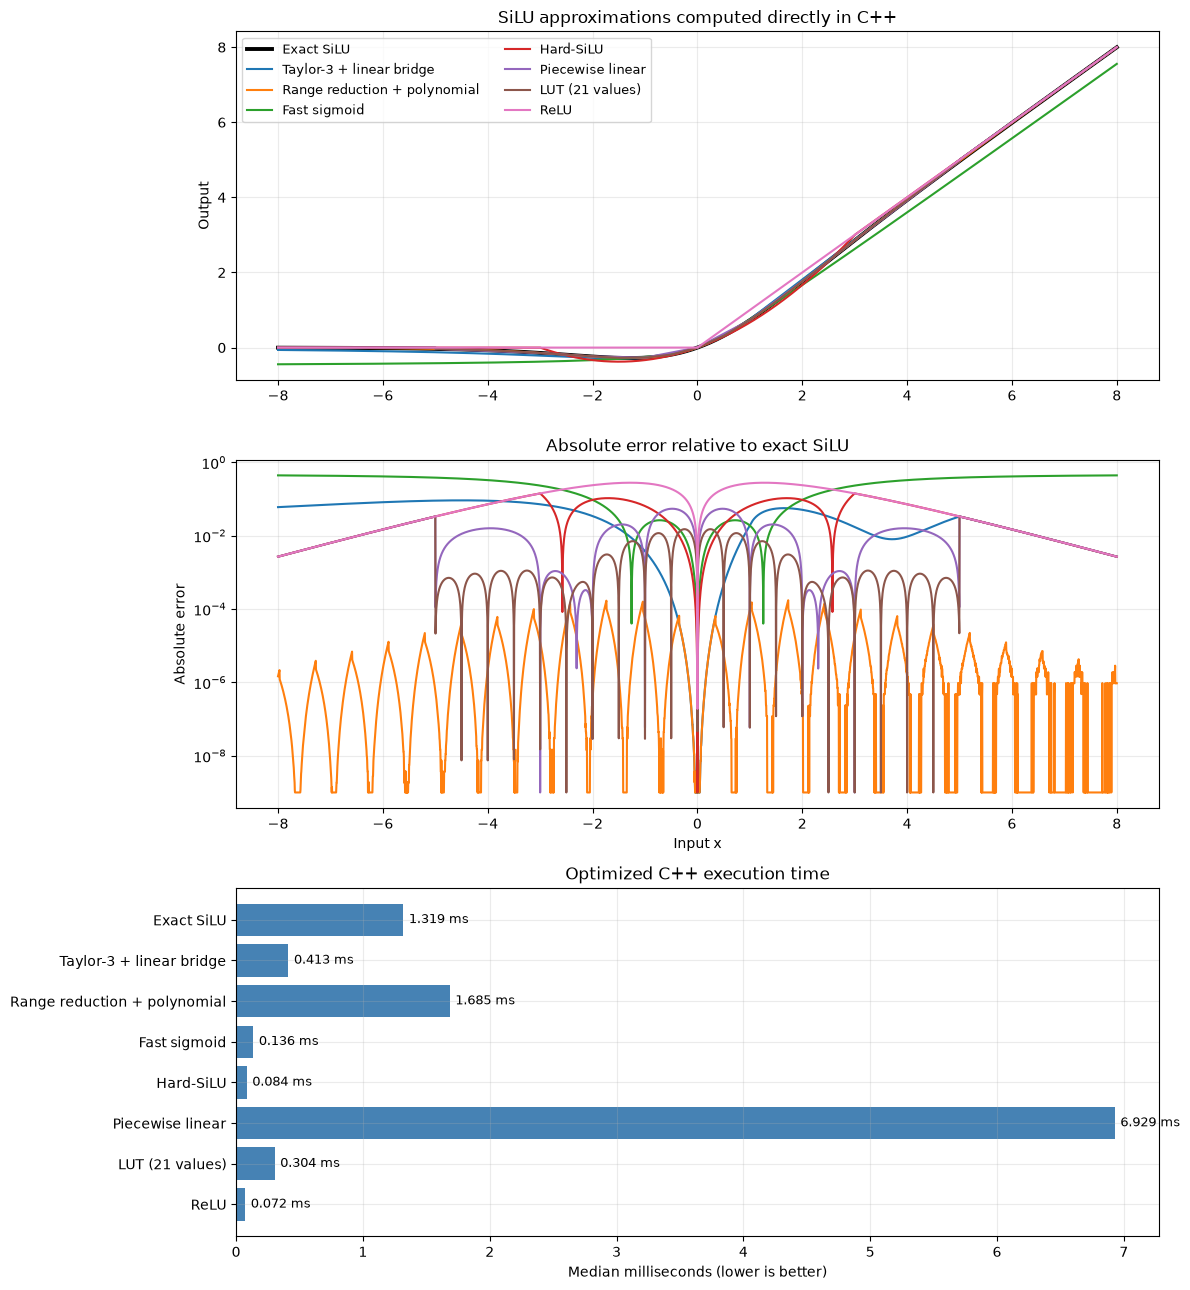

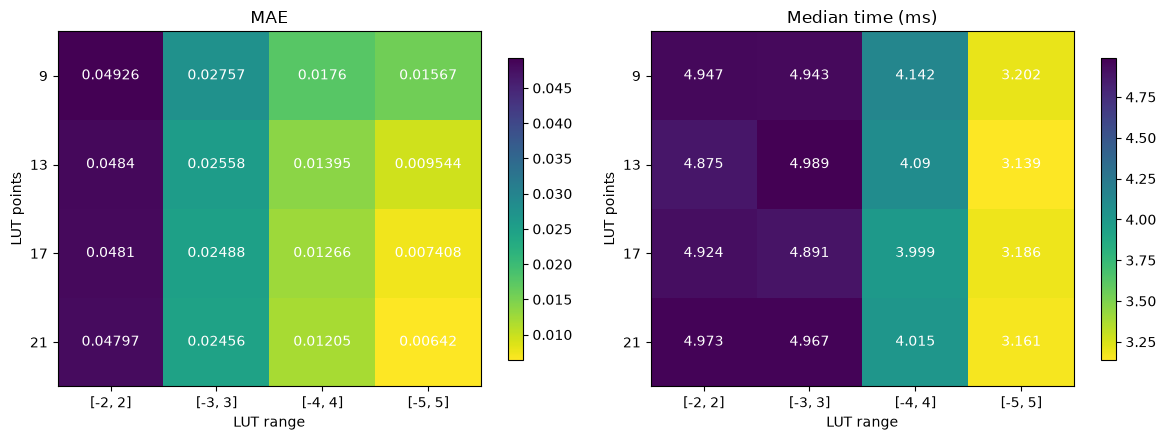

In [3]:
import matplotlib.pyplot as plt

labels = {
    'exact_silu': 'Exact SiLU', 'taylor3': 'Taylor-3 + linear bridge',
    'range_poly': 'Range reduction + polynomial',
    'fast_sigmoid': 'Fast sigmoid', 'hard_silu': 'Hard-SiLU',
    'piecewise_linear': 'Piecewise linear',
    'lut_21': 'LUT (21 values)', 'relu': 'ReLU',
}
x = values['x'].to_numpy()
figure, axes = plt.subplots(3, 1, figsize=(12, 13))
axes[0].plot(x, reference, color='black', linewidth=2.8, label='Exact SiLU')
visible_limit = max(10.0, float(np.max(np.abs(reference))) + 2.0)
for key, label in labels.items():
    if key == 'exact_silu':
        continue
    approximation = values[key].to_numpy()
    axes[0].plot(x, np.where(np.abs(approximation) <= visible_limit, approximation, np.nan), label=label)
    error = np.abs(approximation - reference)
    finite = np.isfinite(error)
    axes[1].semilogy(x[finite], np.maximum(error[finite], 1e-9), label=label)

axes[0].set(title='SiLU approximations computed directly in C++', ylabel='Output')
axes[0].legend(ncol=2, fontsize=9)
axes[1].set(title='Absolute error relative to exact SiLU', xlabel='Input x', ylabel='Absolute error')
bars = axes[2].barh(timings['label'], timings['median_ms'], color='steelblue')
axes[2].invert_yaxis()
axes[2].set(title='Optimized C++ execution time', xlabel='Median milliseconds (lower is better)')
axes[2].bar_label(bars, fmt='%.3f ms', padding=4, fontsize=9)
for axis in axes:
    axis.grid(True, alpha=0.25)
figure.tight_layout()
plot_path = activation_dir / 'silu_comparison_cpp.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()

metrics = [('mae', 'MAE'), ('median_ms', 'Median time (ms)')]
grid_figure, grid_axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, (metric, title) in zip(grid_axes, metrics):
    matrix = grid.pivot(index='points', columns='maximum', values=metric).sort_index().sort_index(axis=1)
    image = axis.imshow(matrix.to_numpy(), aspect='auto', cmap='viridis_r')
    axis.set_xticks(range(len(matrix.columns)), [f'[-{value:g}, {value:g}]' for value in matrix.columns])
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set(xlabel='LUT range', ylabel='LUT points', title=title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(column, row, f'{matrix.iloc[row, column]:.4g}', ha='center', va='center', color='white')
    grid_figure.colorbar(image, ax=axis, shrink=0.85)
grid_figure.tight_layout()
grid_plot_path = activation_dir / 'lut_grid_search.png'
grid_figure.savefig(grid_plot_path, dpi=220, bbox_inches='tight')
plt.show()

## YOLO KITTI activation ablation

Every registered `nn.SiLU` is replaced by each exported C++ activation kernel, including all 16 uniform-LUT point/range combinations. Validation uses the complete KITTI validation split; forward-only latency uses the first 100 images.

In [4]:
import subprocess
import sys

yolo_results_path = activation_dir / 'yolo_kitti_activation_ablation.json'
command = [
    sys.executable, str(activation_dir / 'compare_yolo_activations_kitti.py'),
    '--threads', '1', '--batch', '1', '--workers', '0',
    '--latency-warmup', '5', '--latency-max-images', '100',
    '--results', str(yolo_results_path),
]
subprocess.run(command, cwd=project_root, check=True)

threads: 1
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 182.1±18.2 MB/s, size: 48.8 KB)
val: Scanning /Users/richard/Developer/Dissertation/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 209.2Mit/s 0.0s

=== native_silu ===
latency: median=25.804 ms, p90=28.401 ms, p99=32.982 ms
activation: median=4.651 ms, p90=4.879 ms, p99=6.028 ms, share=18.13%
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.12.1 CPU (Apple M3 Max)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 481.1±633.0 MB/s, size: 49.4 KB)
val: Scanning /Users/richard/Developer/Dissertation/datasets/kitti/labels/val.cache... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 522.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1496/1496 34.9it/s 42.9s
                   all       1496       8128      0.935      0.823      0.903      0.679
Speed: 0.2ms preprocess, 25.4ms inference, 0.0

CompletedProcess(args=['/opt/anaconda3/envs/ultralytics/bin/python', '/Users/richard/Developer/Dissertation/Activation/compare_yolo_activations_kitti.py', '--threads', '1', '--batch', '1', '--workers', '0', '--latency-warmup', '5', '--latency-max-images', '100', '--results', '/Users/richard/Developer/Dissertation/Activation/yolo_kitti_activation_ablation.json'], returncode=0)

,activation,mAP50,mAP50-95,precision,recall,forward_median_ms,activation_median_ms,activation_share_percent,mAP50_change,mAP50-95_change
0,native_silu,0.902543,0.678951,0.935474,0.823328,25.804,4.651,18.13%,+0.000000,+0.000000
1,cpp_exact_silu,0.902544,0.678951,0.935474,0.823328,28.416,6.887,24.30%,+0.000000,+0.000000
2,cpp_taylor3_linear,0.881175,0.636372,0.879457,0.826661,21.757,1.542,7.16%,-0.021368,-0.042580
3,cpp_range_poly,0.902544,0.678925,0.935399,0.823355,29.657,8.602,28.84%,+0.000000,-0.000026
4,cpp_fast_sigmoid,0.723846,0.428435,0.689660,0.683871,21.024,0.954,4.54%,-0.178697,-0.250516
5,cpp_hard_silu,0.869689,0.605472,0.892724,0.823260,20.515,0.671,3.32%,-0.032855,-0.073479
6,cpp_piecewise_linear,0.898467,0.676735,0.918180,0.835966,43.941,21.826,49.61%,-0.004076,-0.002216
7,cpp_lut21,0.903231,0.682805,0.939970,0.824010,22.804,1.785,7.90%,+0.000688,+0.003854
8,cpp_relu,0.000080,0.000016,0.000339,0.023115,21.509,0.646,3.09%,-0.902463,-0.678935
9,cpp_lut9_range2,0.800898,0.536830,0.846105,0.734199,29.157,8.191,28.00%,-0.101645,-0.142121


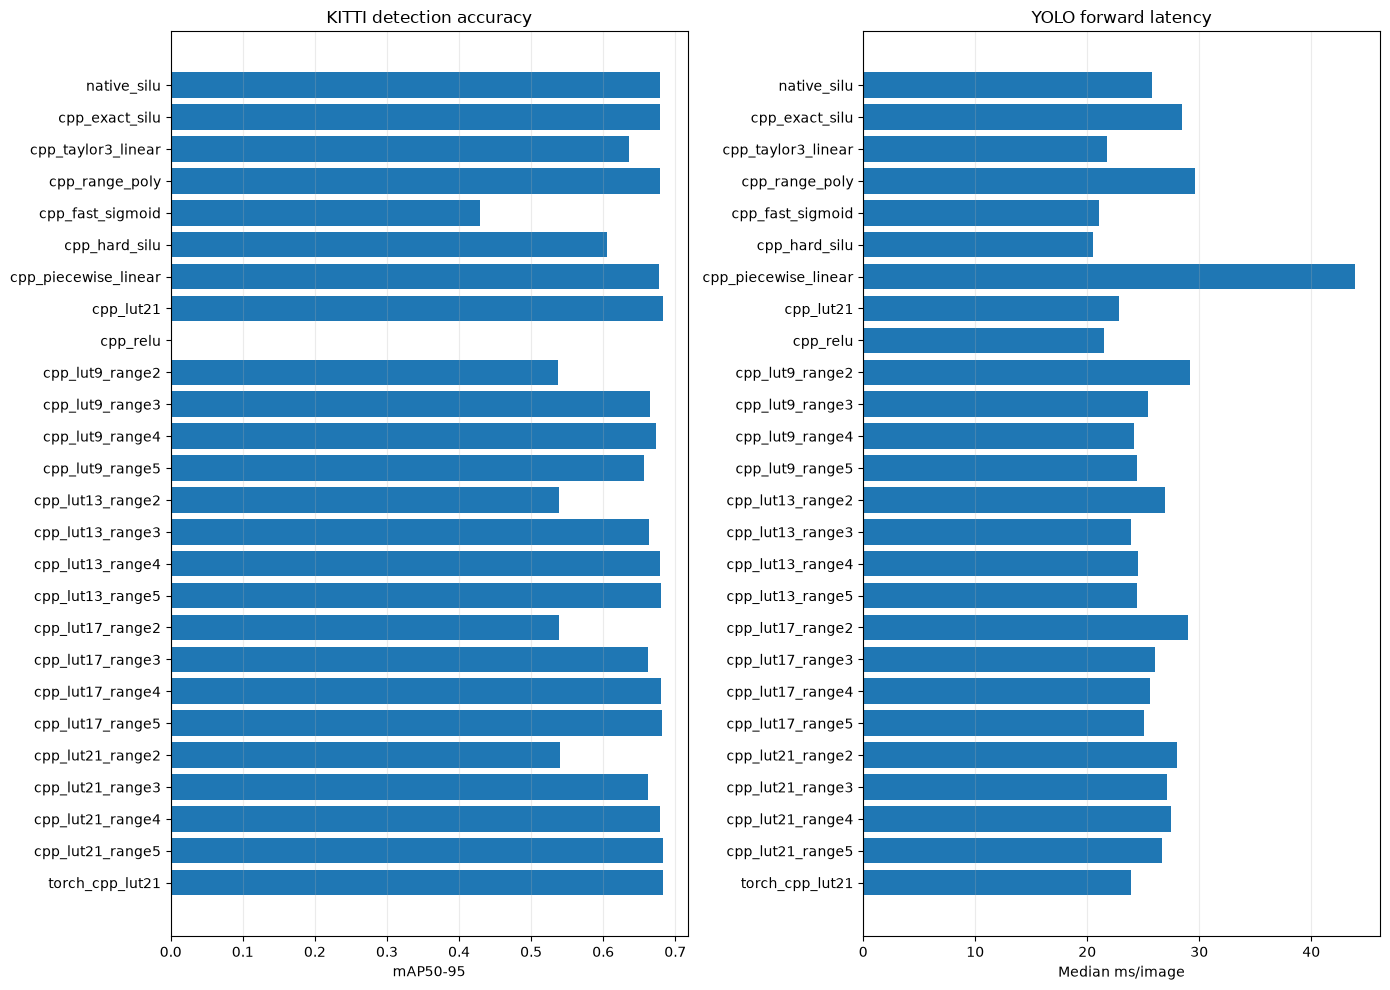

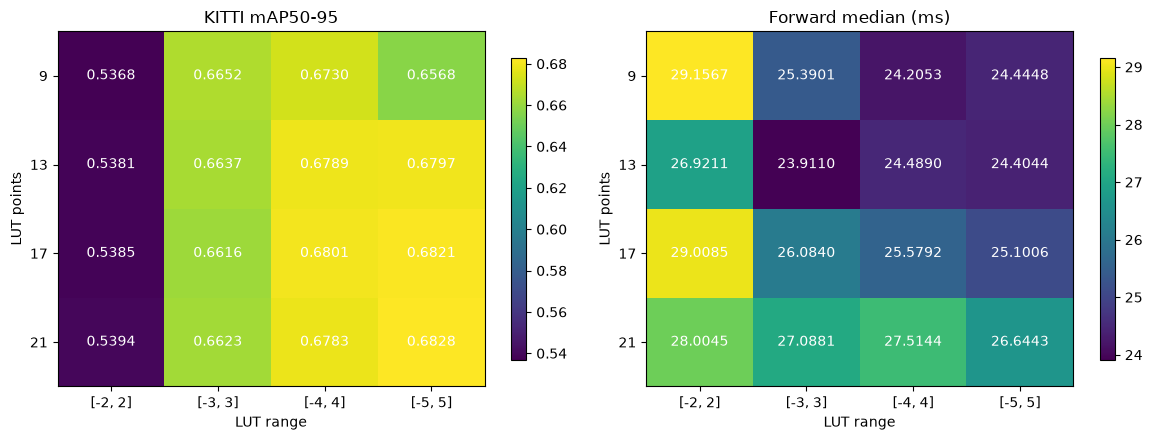

In [5]:
import json

yolo_results = json.loads(yolo_results_path.read_text())
rows = []
for name, entry in yolo_results['comparisons'].items():
    validation = entry['kitti_validation']
    latency = entry['latency']
    activation = latency['activation']
    relative = yolo_results['relative_to_native_silu'].get(name, {})
    rows.append({
        'activation': name,
        'mAP50': validation['map50'],
        'mAP50-95': validation['map50_95'],
        'precision': validation['precision_mean'],
        'recall': validation['recall_mean'],
        'forward_median_ms': latency['median_ms'],
        'activation_median_ms': activation['median_ms'],
        'activation_share_percent': activation['aggregate_wall_clock_percent'],
        'mAP50_change': relative.get('map50_absolute_change', 0.0),
        'mAP50-95_change': relative.get('map50_95_absolute_change', 0.0),
    })
yolo_table = pd.DataFrame(rows)
display(yolo_table.style.format({
    'mAP50': '{:.6f}', 'mAP50-95': '{:.6f}',
    'precision': '{:.6f}', 'recall': '{:.6f}',
    'forward_median_ms': '{:.3f}', 'activation_median_ms': '{:.3f}',
    'activation_share_percent': '{:.2f}%',
    'mAP50_change': '{:+.6f}', 'mAP50-95_change': '{:+.6f}',
}))

figure, axes = plt.subplots(1, 2, figsize=(14, 10))
axes[0].barh(yolo_table['activation'], yolo_table['mAP50-95'])
axes[0].invert_yaxis()
axes[0].set(title='KITTI detection accuracy', xlabel='mAP50-95')
axes[1].barh(yolo_table['activation'], yolo_table['forward_median_ms'])
axes[1].invert_yaxis()
axes[1].set(title='YOLO forward latency', xlabel='Median ms/image')
for axis in axes:
    axis.grid(True, axis='x', alpha=0.25)
figure.tight_layout()
yolo_plot_path = activation_dir / 'yolo_kitti_activation_ablation.png'
figure.savefig(yolo_plot_path, dpi=220, bbox_inches='tight')
plt.show()

lut_yolo = yolo_table[yolo_table['activation'].str.match(r'cpp_lut(9|13|17|21)_range[2345]')].copy()
lut_yolo[['points', 'range']] = lut_yolo['activation'].str.extract(r'cpp_lut(\d+)_range(\d+)').astype(int)
lut_metrics = [('mAP50-95', 'KITTI mAP50-95'), ('forward_median_ms', 'Forward median (ms)')]
lut_figure, lut_axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, (metric, title) in zip(lut_axes, lut_metrics):
    matrix = lut_yolo.pivot(index='points', columns='range', values=metric).sort_index().sort_index(axis=1)
    image = axis.imshow(matrix.to_numpy(), aspect='auto', cmap='viridis')
    axis.set_xticks(range(len(matrix.columns)), [f'[-{value}, {value}]' for value in matrix.columns])
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set(xlabel='LUT range', ylabel='LUT points', title=title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(column, row, f'{matrix.iloc[row, column]:.4f}', ha='center', va='center', color='white')
    lut_figure.colorbar(image, ax=axis, shrink=0.85)
lut_figure.tight_layout()
yolo_lut_plot_path = activation_dir / 'yolo_kitti_lut_grid.png'
lut_figure.savefig(yolo_lut_plot_path, dpi=220, bbox_inches='tight')
plt.show()